# Проект модуля 3. Предсказание возраста посетителей сайтов.

## Цель и задачи.
### Цель:
Увеличение эффективности интернет-рекламы за счет ее возрастного таргетирования на основании профиля поведения пользователей.

### Задачи:
1. Загрузка данных и знакомство с их содержимым.
2. Исследовательский анализ данных.
3. Предобработка данных для машинного обучения.
4. Обучение и оценка базовой модели классификации.
3. Отбор и создание признаков для задачи машинного обучения.
3. Подбор гиперпараметров моделей.
4. Финальное обучение моделей и подготовка артефактов.
5. Формулировка выводов, содержащих оценку и анализ результатов обучения моделей.

### Постановка задачи в терминах машинного обучения
- Необходимо решить задачу машинного обучения для предсказания возрастной категории интернет-пользователя на основе предоставленного датасета с признаками и значениями целевой переменной.
- Тип задачи машинного обучения: многоклассовая классификация.
- Целевая переменная - возрастная категория (см. `age_category` далее).
- Модели машинного обучения - многоклассовая логистическая регрессия и метод опорных векторов (SVM) с линейным и нелинейными ядрами в стратегиях One vs One и One vs Rest.
- Необходимо использовать кросс-валидацию по стратифицированным по значениям целевой переменной фолдам для оценки качества моделей.
- Основная метрика - F1 . Вспомогательные метрики - Precision, Recall. 
- Значение F1-меры лучшей модели должно быть не меньше 0.75 и на кросс-валидации по обучающей выборке, и на тестовой выборке. 
- Необходимо обеспечить воспроизводимость результатов при помощи указания фиксированного значения `random_state`.
- Для тестовой выборки необходимо выделить 20%-30% измерений из датасета.
- Решение должно быть сохранено в виде готового к промышленной эксплуатации пайплайна, включающего предобработку данных и классификатор.

### Описание данных
#### **Таблица `users`**

Таблица `users` содержит информацию о возрастной категории пользователя:

- `user_id` — уникальный идентификатор пользователя.
- `age_category` — возрастная категория пользователя, этот показатель модель должна научиться предсказывать. Содержит следующие категории:
    - `0`: младше 18;
    - `1`: 18-25 лет;
    - `2`: 26-40 лет;
    - `3`: 41-55 лет;
    - `4`: 56+ лет.

#### **Таблица `visits`**

Лог посещений сайтов `visits` похож на данные сервиса веб-аналитики [«Яндекс Метрика»](https://yandex.ru/adv/metrika). Он предназначен для сбора и анализа информации об активности пользователей разных сайтов. Заказчик попросил в целях защиты персональных данных заменить в логах все URL на анонимизированную категорию сайта, а вместо точного времени использовать время суток.

Признаки в датасете:

- `date` — дата посещения сайта.
- `daytime` — анонимизированное время посещения сайта. Категории: `утро`, `день`, `вечер`, `ночь`.
- `session_id` — уникальный идентификатор сессии. Сессия — это последовательность действий пользователя на сайте, которая начинается при первом взаимодействии с ресурсом и завершается по правилам тайм-аута или смены условий.
- `user_id` — уникальный идентификатор пользователя.
- `website_category` — анонимизированная категория сайта. В лог включены несколько десятков категорий, которые позволяют эффективно сегментировать аудиторию. Это позволяет сократить пространство признаков модели без потери её качества.

#### **Таблица `ads_activity`**

Активность взаимодействия пользователя с рекламными объявлениями — важный показатель, связанный с возрастом. Информация об этом признаке представлена в таблице `ads_activity`:

- `user_id` — уникальный идентификатор пользователя.
- `ads_activity` — характеристика CTR, выраженная одним из значений: `очень редко`, `редко`, `умеренно`, `часто`, `очень часто`.

CTR (Click-Through Rate) — термин в интернет-маркетинге, показатель кликабельности. Показывает, как часто люди кликают по объявлению с рекламой, ссылке в поисковой выдаче или кнопке.

#### **Таблица `surf_depth`**

В таблице `surf_depth` содержится два признака:

- `user_id` — уникальный идентификатор пользователя.
- `surf_depth` — категориальная переменная, характеризующая глубину перехода пользователя по сайтам во время одной сессии. Содержит категории `поверхностно`, `средне`, `глубоко`.

#### **Таблица `primary_device`**

Таблица `primary_device` содержит два признака:

- `user_id` — уникальный идентификатор пользователя.
- `primary_device` — информация о типе основного устройства пользователя для выхода в Интернет.

Каждое устройство и браузер, которым человек пользуется для выхода в интернет, имеет свой уникальный идентификатор. Крипта умеет определять, что все эти идентификаторы принадлежат одному пользователю, по схожести его поведения на разных устройствах или по более точным факторам: например, по использованию одного и того же логина. Также учитывается, что одним устройством могут пользоваться сразу несколько человек: члены семьи или коллеги. 

#### **Таблица `cloud_usage`**

Использование облачных технологий описано в файле `cloud_usage`:

- `user_id` — уникальный идентификатор пользователя;
- `cloud_usage` — `True` означает, что пользователь обращается к облачным ресурсам прямо или через посещаемые сайты.


## Структура проекта
1. [Подготовка среды и загрузка данных.](#1-подготовка-среды-и-загрузка-данных)
    - [1.1. Подготовка библиотек.](#11-подготовка-библиотек)
    - [1.2. Фиксация константы для воспроизводимости.](#12-фиксация-константы-для-воспроизводимости)
    - [1.3. Загрузка данных.](#13-загрузка-данных)
    - [1.4. Удаление дубликатов.](#14-удаление-дубликатов)
    - [1.5. Построение профиля пользователя.](#15-построение-профиля-пользователя)
2. [Исследовательский анализ данных.](#2-исследовательский-анализ-данных)
    - [2.1. Исследование целевой переменной.](#21-исследование-целевой-переменной)
    - [2.2. Исследование категориальных признаков.](#22-исследование-категориальных-признаков)
    - [2.3. Исследование числовых признаков.](#23-исследование-числовых-признаков)
    - [2.4. Анализ корреляция признаков.](#24-анализ-корреляций-признаков)
3. [Разделение датасета на выборки и описание пайплайнов.](#3-разделение-датасета-на-выборки-и-описание-пайплайнов)
    - [3.1. Разделение датасета на выборки.](#31-разделение-датасета-на-выборки)
    - [3.2. Описание функций для построения пайплайнов.](#32-описание-функций-для-построения-пайплайнов)
4. [Отбор признаков.](#4-отбор-признаков)
    - [4.1. Корреляции целевой переменной.](#41-корреляции-целевой-переменной)
    - [4.2. Метрика взаимной информации с целевой переменной (Mutual Information).](#42-метрика-взаимной-информации-с-целевой-переменной-mutual-information)
    - [4.3. Методы-обёртки (Recursive Feature Elimination.)](#43-методы-обёртки-recursive-feature-elimination)
    - [4.4. Константные признаки.](#44-константные-признаки)
    - [4.5. Формирование набора признаков для обучения.](#45-формирование-набора-признаков-для-обучения)
5. [Обучение моделей.](#5-обучение-моделей)
    - [5.1. Обучение базовой модели `DummyClassifier`.](#51-обучение-базовой-модели-dummyclassifier)
    - [5.2. Обучение модели многоклассовой логистической регрессии с параметрами по умолчанию.](#52-обучение-модели-многоклассовой-логистической-регрессии-с-параметрами-по-умолчанию)
    - [5.3. Обучение модели `SVC` с параметрам ипо умолчанию и `OneVsRestClassifier`.](#53-обучение-модели-svc-с-параметрами-по-умолчанию-и-onevsrestclassifier)
6. [Подбор гиперпараметров.](#6-подбор-гиперпараметров)
    - [6.1. Подбор гиперпараметров логистической регрессии.](#61-подбор-гиперпараметров-логистической-регрессии)
    - [6.2. Подбор гиперпараметров `SVC`.](#62-подбор-гиперпараметров-svc)
7. [Обучение финальной модели.](#7-обучение-финальной-модели)
8. [Сохранение и проверка артефактов.](#8-сохранение-и-проверка-артефактов)
    - [8.1. Сохранение артефактов.](#81-сохранение-артефактов)
    - [8.2. Проверка артефактов.](#82-проверка-артефактов)
9. [Выводы.](#9-выводы)

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовка библиотек
- Установка необходимых пакетов:

In [1]:
%pip install -q numpy==1.23
%pip install -q --upgrade scikit-learn
%pip install -q --upgrade seaborn
%pip install -q --upgrade jinja2
%pip install -q phik
%pip install -q mlxtend

# Сохраним версии библиотек в requirements.txt
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\TEXNH MAKPH\Projects\Yandex DS\ds-yandex\.venv\Lib\site-packages\pip\_internal\cli\base_command.py", line 107, in _run_wrapper
    status = _inner_run()
  File "c:\Users\TEXNH MAKPH\Projects\Yandex DS\ds-yandex\.venv\Lib\site-packages\pip\_internal\cli\base_command.py", line 98, in _inner_run
    return self.run(options, args)
           ~~~~~~~~^^^^^^^^^^^^^^^
  File "c:\Users\TEXNH MAKPH\Projects\Yandex DS\ds-yandex\.venv\Lib\site-packages\pip\_internal\cli\req_command.py", line 96, in wrapper
    return func(self, options, args)
  File "c:\Users\TEXNH MAKPH\Projects\Yandex DS\ds-yandex\.venv\Lib\site-packages\pip\_internal\commands\install.py", line 392, in run
    requirement_set = resolver.resolve(
        reqs, check_supported_wheels=not options.target_dir
    )
  File "c:\Users\TEXNH MAK

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


- Импортируем необходимые пакеты:

In [2]:
import pandas as pd
import numpy as np
import phik

# Библиотеки машинного обучения
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.frozen import FrozenEstimator
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, \
    average_precision_score, log_loss, recall_score, precision_score, brier_score_loss, \
    confusion_matrix
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

# Библиотеки для построения графиков
import seaborn as sns
import matplotlib.pyplot as plt

# Сериализация пайплайна
import joblib

# Для форматирования в HTML
from IPython.display import display, HTML, Markdown

#### 1.2 Фиксация константы для воспроизводимости
- Зафиксируем значение `random_state` для воспроизводимости результатов:

In [3]:
RANDOM_SEED=42

#### 1.3 Загрузка данных
- Загрузим данные из датасета и выведем основные сведения о них:

In [4]:
def load_dataset(file_name):
    base_url = 'https://code.s3.yandex.net/'
    try:
        # Сначала загрузим данныз из локального файла
        return pd.read_csv(file_name)
    except FileNotFoundError:
        # Если файла нет, загружаем по сети
        return pd.read_csv(base_url + file_name)
    
df_users = load_dataset('datasets/ds_s13_users.csv')
df_visits = load_dataset('datasets/ds_s13_visits.csv')
df_ads_activity = load_dataset('datasets/ads_activity.csv')
df_surf_depth = load_dataset('datasets/surf_depth.csv')
df_primary_device = load_dataset('datasets/primary_device.csv')
df_cloud_usage = load_dataset('datasets/cloud_usage.csv')

dfs = [df_users, df_visits, df_ads_activity, df_surf_depth, df_primary_device,
       df_cloud_usage]

def show_df_info(dfs, names):
    for df, name in zip(dfs, names):
        display(HTML('<h2>Таблица ' + name + '</h2>'))
        display(df.info())
        display(df.head(10))
        display(HTML(f'''<b>Количество явных дубликатов: {df.duplicated().sum()}<br> 
            Максимальное количество записей для одного user_id: 
                     {df.groupby(by='user_id').size().max()}</b>'''))

show_df_info(dfs, ['users', 'visits', 'ads_activity', 
                          'surf_depth', 'primary_device', 'cloud_usage'])


<class 'pandas.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5913 non-null   str  
 1   age_category  5913 non-null   int64
dtypes: int64(1), str(1)
memory usage: 92.5 KB


None

,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0
5,348c-35488a73fb49d5b0449e-1920481e,0
6,f3cd-a32250aea93b5a3d6e48-2f6d3c21,2
7,d289-e3226cd63d5718a55b6e-4fcb65c0,4
8,b5ff-7828dbb91d99930fcc3f-48617440,4
9,5614-40eb0cb16aae973189dd-58d4abb3,4


<class 'pandas.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype
---  ------            --------------    -----
 0   date              1065745 non-null  str  
 1   daytime           1065745 non-null  str  
 2   session_id        1065745 non-null  str  
 3   user_id           1065745 non-null  str  
 4   website_category  1065745 non-null  str  
dtypes: str(5)
memory usage: 40.7 MB


None

...

None

,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК
5,b252-4ef81d7eb4d08e7cfca3-8ab368c3,ПК
6,cf6c-8e40f0911cda3887386b-2a2ba17c,смартфон
7,d548-dcf590448cab64164ceb-9438f37d,планшет
8,05ce-a078ac0dc4bb3c6e7c85-a18923e0,планшет
9,e24f-3c900f4e1c090af800c4-14c13da3,смартфон


<class 'pandas.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      5680 non-null   str  
 1   cloud_usage  5680 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 50.1 KB


None

,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False
5,eec4-ba0e8feda1f4905f3d3d-8dca4ae5,False
6,055a-073f4618b55436f41f81-1f2d7d6f,True
7,b41c-a3e6a59e9b11f68bb6b7-90bd2a1e,False
8,ef6e-8deb3c158fa74aed8af5-a3412641,False
9,d8ed-37f46ad2607209a2eee3-2d85128e,False


#### 1.4. Удаление дубликатов
- В таблицах `users`, `visits`, `ads_activity` найдены дубликаты. В таблице `visits` они вполне возможны, так как в течение дня и в рамках одной сессии пользователь может совершать множество действий. В остальных таблицах дубликаты ошибочны и должны быть удалены:

In [5]:
df_users.drop_duplicates(inplace=True)
df_ads_activity.drop_duplicates(inplace=True)

show_df_info([df_users, df_ads_activity], ['df_users', 'df_ads_activity'])

<class 'pandas.DataFrame'>
Index: 5826 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5826 non-null   str  
 1   age_category  5826 non-null   int64
dtypes: int64(1), str(1)
memory usage: 136.5 KB


None

,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0
5,348c-35488a73fb49d5b0449e-1920481e,0
6,f3cd-a32250aea93b5a3d6e48-2f6d3c21,2
7,d289-e3226cd63d5718a55b6e-4fcb65c0,4
8,b5ff-7828dbb91d99930fcc3f-48617440,4
9,5614-40eb0cb16aae973189dd-58d4abb3,4


<class 'pandas.DataFrame'>
Index: 5593 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5593 non-null   str  
 1   ads_activity  5593 non-null   str  
dtypes: str(2)
memory usage: 131.1 KB


None

,user_id,ads_activity
0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто
1,35cd-a972339dec534f49332c-a8b6d383,редко
2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко
3,5186-e25a37549e50f45b2b43-178eaabe,умеренно
4,febd-077f277466253ee04ef6-42656680,умеренно
5,f00c-1bf1415b4377c2c229ee-cef74c27,умеренно
6,55ba-bb355dd086987f5f390f-508cb1cc,умеренно
7,ff8f-8167e729650d17c3add4-205d9000,очень редко
8,dcdf-429ea4cf29bc0f31762d-041e3a8c,редко
9,e57e-1590a765ad1fbfb7b81b-82ebe9fb,очень редко


#### 1.5. Построение профиля пользователя
Для построения профиля пользователя необходимо рассчитать агрегатные признаки для каждого `user_id`, на которых в дальнейшем будут обучены модели классификации.
- Получим диапазон дат, за которые собраны данные:

In [6]:
print(f"Диапазон дат: с {df_visits['date'].min()} по {df_visits['date'].max()}")

Диапазон дат: с 2025-11-01 по 2025-11-14


- Данные представлены за 14 дней ноября 2025 года. На таком небольшом интервале нельзя выделить недельные или месячные колебания, поэтому даты и их составляющие можно убрать из признаков при агрегации.
- Построим сводную таблицу на базе `visits` с агрегацией по категориям (суммарное количество посещений) и времени суток (суммарное количество посещений и количество уникальных сессий).
- В сводной таблице переименуем столбцы, чтобы их названия были английскими, в стиле snake case.

In [7]:
def aggregate_visits(df_visits):
    
    # Сводная таблица со столбцами по категориям daytime
    df_visits_daytime = df_visits.pivot_table(index='user_id',
                                            columns='daytime',
                                            values='session_id',
                                            aggfunc=['count', 'nunique'],
                                            fill_value=0)

    # Переименуем столбцы
    cols_to_rename = {
        'вечер': 'evening',
        'ночь': 'night',
        'день': 'day',
        'утро': 'morning'    
    }
    df_visits_daytime.rename(columns=cols_to_rename, inplace=True)
    df_visits_daytime.columns = [f'{cat}_{agg}' for cat, agg in df_visits_daytime.columns]

    # Сводная таблица со столбцами по категориям website_category
    df_visits_category = df_visits.pivot_table(index='user_id',
                                            columns='website_category',
                                            values='session_id',
                                            aggfunc='count',
                                            fill_value=0)
    # Переименуем столбцы
    cols_to_rename = {f'Category {i:02}': f'cat_{i:02}' for i in range(1, 21)}
    df_visits_category.rename(columns=cols_to_rename, inplace=True)

    # Сводная таблица по дням и user_id
    df_visits_pivot = df_visits_daytime.join(df_visits_category, how='outer')
    df_visits_pivot.reset_index(inplace=True)

    return df_visits_pivot

df_visits_pivot = aggregate_visits(df_visits)
display(df_visits_pivot.info())
display(df_visits_pivot.head())

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   user_id          5826 non-null   str  
 1   count_evening    5826 non-null   int64
 2   count_day        5826 non-null   int64
 3   count_night      5826 non-null   int64
 4   count_morning    5826 non-null   int64
 5   nunique_evening  5826 non-null   int64
 6   nunique_day      5826 non-null   int64
 7   nunique_night    5826 non-null   int64
 8   nunique_morning  5826 non-null   int64
 9   cat_01           5826 non-null   int64
 10  cat_02           5826 non-null   int64
 11  cat_03           5826 non-null   int64
 12  cat_04           5826 non-null   int64
 13  cat_05           5826 non-null   int64
 14  cat_06           5826 non-null   int64
 15  cat_07           5826 non-null   int64
 16  cat_08           5826 non-null   int64
 17  cat_09           5826 non-null   int64
 18  cat_10           58

None

,user_id,count_evening,count_day,count_night,count_morning,nunique_evening,nunique_day,nunique_night,nunique_morning,cat_01,...,cat_11,cat_12,cat_13,cat_14,cat_15,cat_16,cat_17,cat_18,cat_19,cat_20
0,0010-5cf8f6b38a7b6c70a021-009dbcda,227,182,54,92,226,178,52,90,16,...,32,44,12,19,15,33,28,44,50,51
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,52,69,17,49,51,69,16,49,15,...,13,0,12,7,3,8,12,17,1,4
2,0014-d3032d60979a8d2b3077-f09bdce8,36,47,11,26,36,45,11,25,1,...,0,7,20,8,8,2,9,3,12,4
3,001a-eee53e44f848608779b0-78704a67,121,96,32,42,119,96,31,41,19,...,14,19,0,28,12,9,13,21,21,17
4,002c-40a064b12e1217e12207-a56eaf3b,150,192,34,124,145,188,34,123,0,...,19,43,83,0,22,20,18,6,25,28


- Соединим все таблицы в один датафрейм по `user_id`:

In [8]:
def join_tables(df_users, df_ads_activity, df_cloud_usage, df_primary_device, df_visits_pivot):
      df_user_props = (df_users.merge(df_surf_depth, on='user_id', how='left')
            .merge(df_ads_activity, on='user_id', how='left')
            .merge(df_cloud_usage, on='user_id', how='left')
            .merge(df_primary_device, on='user_id', how='left'))
      df = df_user_props.merge(df_visits_pivot, on='user_id', how='left')

      return df

df = join_tables(df_users, df_ads_activity, df_cloud_usage, df_primary_device, df_visits_pivot)

display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 34 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user_id          5826 non-null   str   
 1   age_category     5826 non-null   int64 
 2   surf_depth       5715 non-null   str   
 3   ads_activity     5593 non-null   str   
 4   cloud_usage      5680 non-null   object
 5   primary_device   5669 non-null   str   
 6   count_evening    5826 non-null   int64 
 7   count_day        5826 non-null   int64 
 8   count_night      5826 non-null   int64 
 9   count_morning    5826 non-null   int64 
 10  nunique_evening  5826 non-null   int64 
 11  nunique_day      5826 non-null   int64 
 12  nunique_night    5826 non-null   int64 
 13  nunique_morning  5826 non-null   int64 
 14  cat_01           5826 non-null   int64 
 15  cat_02           5826 non-null   int64 
 16  cat_03           5826 non-null   int64 
 17  cat_04           5826 non-null   int64 
 18 

None

- Пропуски присутствуют в столбцах `surf_depth`, `ads_activity`, `cloud_usage`, `primary_device`. В булевом столбце `cloud_usage`, вероятно, значение отсутствует для пользователей, не зарегистрированных в облачном сервисе, поэтому его можно заменить на `False` и преобразовтаь столбец к булевому типу. Пропуски в остальных столбцах заменим на индикатор `Unknown`.
- Переименуем столбцы, чтобы их названия были английскими в стиле snake case.
- Добавим столбец `total` с суммарным количеством обращений и столбец `total_unique` с количеством уникальных сессий.
- Столбцы с суммарным количеством обращений по категориям и времени суток заменим на их долю от общего числа.
- Столбцы с количеством уникальных сессий по категориям заменим на их долю от общего числа сессий.

In [9]:
# Заполнение пропусков и формирование дополнительных признаков
def update_features(df):
    df['cloud_usage'] = pd.to_numeric(df['cloud_usage'].fillna(False))
    df['surf_depth'] = df['surf_depth'].fillna('Unknown')
    df['ads_activity'] = df['ads_activity'].fillna('Unknown')
    df['primary_device'] = df['primary_device'].fillna('Unknown')

    df['total'] = df['count_morning'] + df['count_day'] + \
                    df['count_evening'] + df['count_night']
    df['total_unique'] = df['nunique_morning'] + df['nunique_day'] + \
                    df['nunique_evening'] + df['nunique_night']
    
    cols1 = ['count_morning',
            'count_day',
            'count_evening',
            'count_night']
    cols1.extend([f'cat_{i:02}' for i in range(1, 21)])
    df[cols1] = df[cols1].astype('float64').div(df['total'], axis=0)

    cols2 = ['nunique_morning',
             'nunique_day',
             'nunique_evening',
             'nunique_night']
    df[cols2] = df[cols2].astype('float64').div(df['total_unique'], axis=0)
    return df

df = update_features(df)

display(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 36 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   user_id          5826 non-null   str    
 1   age_category     5826 non-null   int64  
 2   surf_depth       5826 non-null   str    
 3   ads_activity     5826 non-null   str    
 4   cloud_usage      5826 non-null   bool   
 5   primary_device   5826 non-null   str    
 6   count_evening    5826 non-null   float64
 7   count_day        5826 non-null   float64
 8   count_night      5826 non-null   float64
 9   count_morning    5826 non-null   float64
 10  nunique_evening  5826 non-null   float64
 11  nunique_day      5826 non-null   float64
 12  nunique_night    5826 non-null   float64
 13  nunique_morning  5826 non-null   float64
 14  cat_01           5826 non-null   float64
 15  cat_02           5826 non-null   float64
 16  cat_03           5826 non-null   float64
 17  cat_04           5826 non

None

,user_id,age_category,surf_depth,ads_activity,cloud_usage,primary_device,count_evening,count_day,count_night,count_morning,...,cat_13,cat_14,cat_15,cat_16,cat_17,cat_18,cat_19,cat_20,total,total_unique
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,глубоко,Unknown,False,смартфон,0.333333,0.359375,0.078125,0.229167,...,0.031250,0.036458,0.052083,0.041667,0.057292,0.067708,0.072917,0.041667,192,187
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,средне,умеренно,False,смартфон,0.395833,0.333333,0.090278,0.180556,...,0.034722,0.000000,0.062500,0.034722,0.041667,0.027778,0.034722,0.034722,144,141
2,678b-614cd47d854b9d591db2-000b2e50,0,средне,умеренно,False,смартфон,0.372549,0.303922,0.127451,0.196078,...,0.127451,0.009804,0.019608,0.029412,0.019608,0.009804,0.117647,0.058824,102,100
3,4ac0-dad169100b4a29b20818-b26ae7c5,4,поверхностно,редко,True,смартфон,0.260870,0.438735,0.071146,0.229249,...,0.079051,0.019763,0.027668,0.027668,0.063241,0.138340,0.035573,0.011858,253,248
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0,поверхностно,очень редко,True,смартфон,0.418033,0.336066,0.073770,0.172131,...,0.000000,0.090164,0.024590,0.032787,0.049180,0.032787,0.024590,0.057377,122,119


#### Выводы:
- Был представлен датасет, состоящий из 5 таблиц в формате CSV.
- Датасет был проанализирован на наличие дубликатов. Дубликаты были найдены в трех таблицах: `users`, `visits`, `ads_activity`. Наличие дубликатов в таблице `visits` не является ошибкой; в остальных таблицах дубликаты были удалены.
- После удаления дубликатов количество пользователей в датасете `users` равно 5826.
- Таблица `visits` была преобразована в сводную путем подсчета количества строк в каждой из категорий, задаваемых столбцами `daytime`, `website_category`. Для категорий времени дня были дополнительно добавлены столбцы с количеством уникальных сессий.
- Все таблицы датасета были объединены в единый датафрейм пр помощи внешних соединений с таблицей `users` по полю `user_id`.
- Пропуски в столбцах, появившиеся в результате внешних соединений были заполнены следующим образом: 
    1. В столбце `cloud_usage` - значением `False`;
    2. В столбцах `surf_depth`, `ads_activity`, `primary_device` - значением-индикатором `Unknown`.
- Был добавлен признак `total` с суммарным количеством обращений и признак `total_unique` с количеством уникальных сессий.
- Столбцы с суммарным количеством обращений по категориям и времени суток заменены на их долю от общего числа.
- Столбцы с количеством уникальных сессий по категориям заменены на их долю от общего числа сессий.

## 2. Исследовательский анализ данных
- Описание функций для построения графиков и диаграмм:

In [10]:
# Функция для построения скаттерплота в сетке
def draw_scatterplot_grid(data, 
                     title, 
                     x, 
                     y, 
                     hue,
                     xlabel, 
                     ylabel,
                     ax):
    sns.scatterplot(data=data, 
                    x=x,
                    y=y,
                    hue=hue, 
                    ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

# Функция для построения боксплота в сетке
def draw_boxplot_grid(data,
                    field,
                    title, 
                    xlabel, 
                    ylabel, 
                    **kwargs):
    sns.boxplot(data=data,
                x=field,   
                showmeans=True,
                legend=False,
                meanprops={
                    'marker': 'o',
                    'markerfacecolor': 'white',
                    'markeredgecolor': 'black',
                    'markersize': 8
                },
                orient='h',
                **kwargs)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

# Функция для построения гистограммы
def draw_histogram(data,
                    field,
                    title,
                    xlabel, 
                    ylabel,
                    figsize=(12,6),
                    **kwargs):
    sns.histplot(data=data,
                x=field,
                 **kwargs)

    plt.figure(figsize=figsize)
    plt.title(title)
    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Функция для построения гистограммы в сетке
def draw_histogram_grid(data,
                        field,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    sns.histplot(data=data,
                x=field,
                 **kwargs)

    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

# Функция для построения столбчатой диаграммы в сетке
def draw_barplot_grid(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot, 
                 vertical, 
                 mean,
                 ax):
    series.head(20).plot(
        title=title,
        kind='bar' if vertical else 'barh',
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot,
        ax=ax)
    
    if mean != None:
        if vertical:
            ax.axhline(mean, color='red', linestyle='--')
        else:
            ax.axvline(mean, color='red', linestyle='--')    

# Функция для построения тепловой карты
def draw_heatmap(df, title, figsize=(14,14), font_scale=0.6):
    plt.figure(figsize=figsize)
    plt.title(title)
    sns.set_theme(font_scale=font_scale)
    sns.heatmap(data=df, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()    

# Функция для построения гистограммы и боксплота на одной шкале
def draw_double_diag(data, title, x, hue, xlabel, ylabel, stat='count', figsize=(12, 6), bins='auto', kde=True):
    fig, (ax_hist, ax_box) = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        figsize=figsize,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    sns.boxplot(data=data,
                ax=ax_box,
                x=x, 
                hue=hue, 
                showmeans=True,
                legend=False,
                meanprops={
                    'marker': 'o',
                    'markerfacecolor': 'white',
                    'markeredgecolor': 'black',
                    'markersize': 8
                })

    ax_box.set_xlabel('')  # Убираем подпись оси X, чтобы не дублировалась
    ax_box.set_ylabel('')  # Убираем подпись оси Y
    ax_box.set_yticks([])  # Убираем тики оси Y (они не нужны)

    sns.histplot(data=data,
                ax=ax_hist,
                x=x,
                hue=hue,
                kde=kde,
                bins=bins,
                stat=stat)

    ax_hist.set_xlabel(xlabel)
    ax_hist.set_ylabel(ylabel)

    fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

    # Функция для построения столбчатой диаграммы
def draw_barplot(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None):
    series.plot(
        title=title,
        kind='bar' if vertical else 'barh',
        figsize=(8, 4) if vertical else (12, 4),
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot)
    
    if mean != None:
        if vertical:
            plt.axhline(mean, color='red', linestyle='--')
        else:
            plt.axvline(mean, color='red', linestyle='--')
    plt.show()

- Разделение признаков на числовые и категориальные:

In [11]:
num_features = [
    'count_morning',
    'nunique_morning',
    'count_day',
    'nunique_day',
    'count_evening',
    'nunique_evening',
    'count_night',
    'nunique_night',
    'total',
    'total_unique'
]
num_features.extend([f'cat_{i:02}' for i in range(1, 21)])

cat_features = [
    'surf_depth',
    'ads_activity',
    'primary_device'
]

bool_features = ['cloud_usage']
target = 'age_category'

#### 2.1. Исследование целевой переменной
- Исследуем распределение классов целевой переменной:

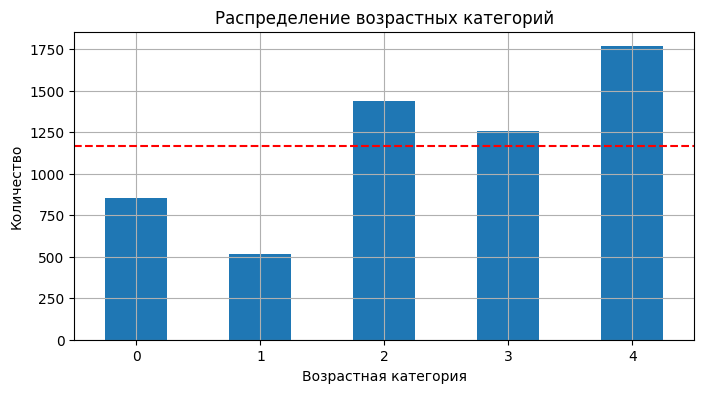

In [12]:
age_cat_qty_mean = df_users['age_category'].value_counts().mean()
draw_barplot(df_users['age_category'].value_counts().sort_index(), 
             "Распределение возрастных категорий", 
             "Возрастная категория",
             "Количество",
             mean=age_cat_qty_mean)

- Классы не сбалансированы. Самый многочисленный класс более, чем в 3 раза превосходит самый маленький.

#### 2.2. Исследование категориальных признаков
- Построим диаграммы распределения категориальных признаков:

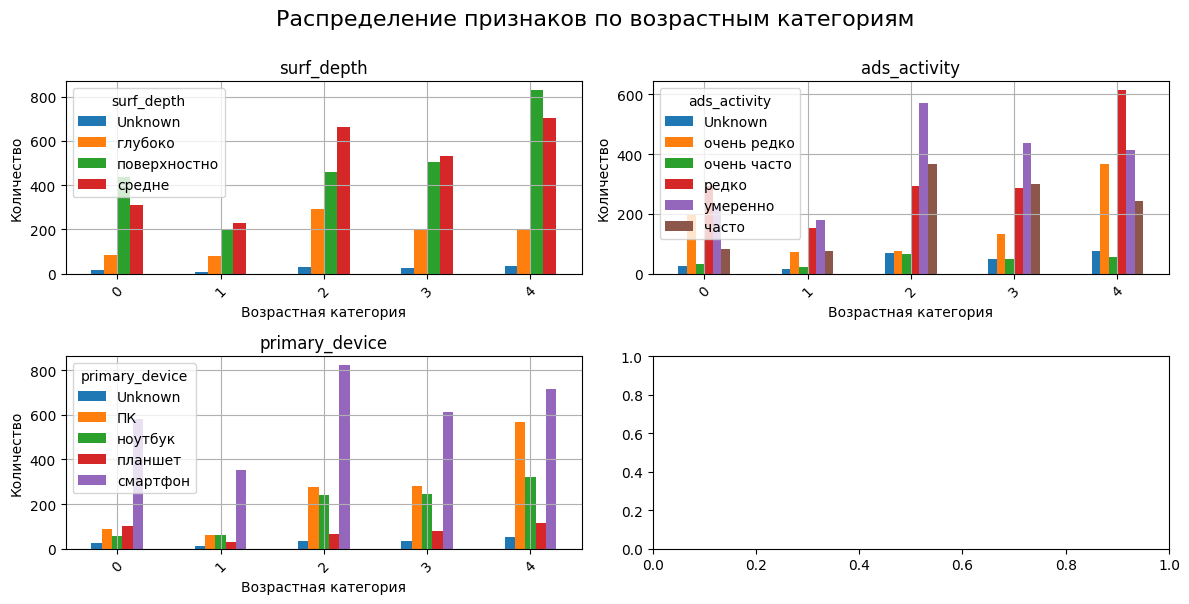

In [13]:
n_lines = round(len(cat_features) / 2)
fig, axes = plt.subplots(n_lines, 2, 
                         figsize=(12, n_lines * 3))

# Построим диаграммы для категориальных признаков в сетке
for i in range(min(n_lines * 2, len(cat_features))):
    draw_barplot_grid(
            (df
             .groupby('age_category')[cat_features[i]]
             .value_counts()
             .unstack(fill_value=0)),
            cat_features[i], 
            "Возрастная категория", 
            "Количество", 
            45, 
            True, 
            None,
            axes[i // 2][i % 2])

plt.suptitle("Распределение признаков по возрастным категориям", fontsize=16, y=1)
plt.tight_layout()
plt.show()   

- По всем признакам заметны различия в профилях поведения пользоваелей из различных возрастных групп: с увеличением возраста увеличивается количество пользователей, просматривающих сайты поверхностно.
- Наибольшую активность в просмотре рекламы проявляют пользователи среднего возраста.
- Пользователи старшего возраста чаще пользуются ПК как основным устройством. Пользователи младшего возраста редко используют ноутбук.

#### 2.3. Исследование числовых признаков
- Построим распределения числовых признаков:

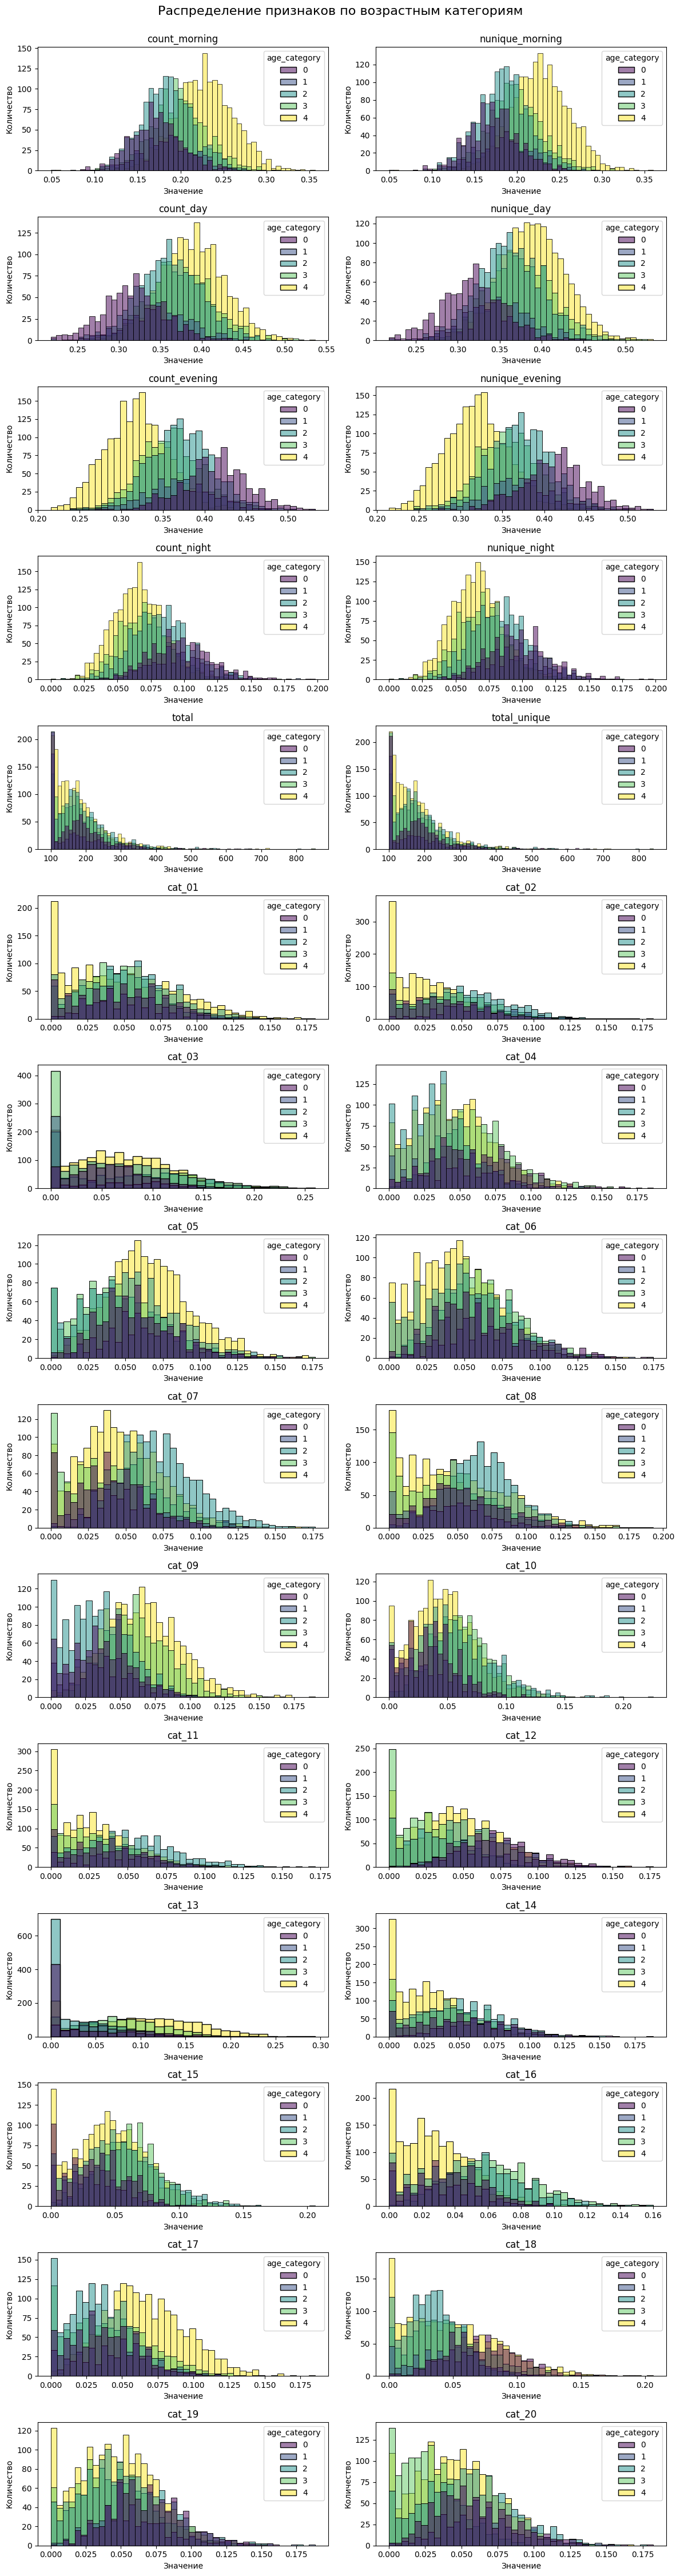

,count_morning,nunique_morning,count_day,nunique_day,count_evening,nunique_evening,count_night,nunique_night,total,total_unique,...,cat_11,cat_12,cat_13,cat_14,cat_15,cat_16,cat_17,cat_18,cat_19,cat_20
count,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,...,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000
mean,0.198743,0.198733,0.364979,0.364961,0.358154,0.358199,0.078124,0.078108,182.929111,180.225712,...,0.036861,0.047751,0.064476,0.043429,0.048661,0.043195,0.046993,0.048015,0.051967,0.047882
std,0.038321,0.038134,0.045456,0.045206,0.049283,0.048836,0.024757,0.024633,76.390669,75.186802,...,0.027077,0.030498,0.057112,0.029839,0.028606,0.028470,0.029178,0.031817,0.028808,0.029157
min,0.049020,0.049505,0.217822,0.217822,0.215517,0.214286,0.000000,0.000000,100.000000,100.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.172414,0.172575,0.335106,0.335058,0.323651,0.324324,0.060811,0.060606,126.000000,124.000000,...,0.015957,0.024707,0.008075,0.019802,0.028746,0.021173,0.025424,0.024631,0.030870,0.026524
50%,0.196532,0.196765,0.365269,0.365385,0.357694,0.357542,0.076271,0.076142,169.000000,167.000000,...,0.033725,0.046358,0.057143,0.041176,0.047619,0.040604,0.045137,0.044444,0.050000,0.045455
75%,0.223847,0.223863,0.395512,0.395664,0.392014,0.391304,0.093567,0.093407,217.000000,213.000000,...,0.054264,0.067961,0.103226,0.063213,0.067308,0.060297,0.065185,0.067568,0.070000,0.066938
max,0.356436,0.360000,0.536364,0.532710,0.532468,0.530000,0.198020,0.198020,853.000000,839.000000,...,0.171429,0.177305,0.293919,0.188119,0.205882,0.160000,0.185185,0.206349,0.188119,0.182171


In [14]:
n_lines = round(len(num_features) / 2)
fig, axes = plt.subplots(n_lines, 2, 
                         figsize=(12, n_lines * 3))

for i in range(min(n_lines * 2, len(num_features))):
    draw_histogram_grid(
            df,
            num_features[i],
            num_features[i], 
            "Значение",
            "Количество",  
            ax=axes[i // 2][i % 2],
            hue='age_category',
            palette='viridis'
            )

plt.suptitle("Распределение признаков по возрастным категориям", fontsize=16, y=1)
plt.tight_layout()
plt.show()

# for i in range(5):
#     draw_histogram(df[df['age_category'] == i][['count_morning', 'count_day', 'count_evening', 'count_night']],None, "Время активности", "Доля", "Количество")

display(df[num_features].describe())

- Профили активности пользователей по времени суток показывают, что утром и днём выше относительная активность пользователей старшего возраста, а вечером и ночью - наоборот.
- Профили посещаемости различных категорий сайтов демонстрируют различие в поведении пользователей разных возрастных категорий. Нулевые значения в столбцах не являются аномальными значениями, они также распределены по возрастным категориями по-разному и важны для классификации, так как показывают, какие категории сайтов вообще не посещаются пользователями.
- Распределения признаков `total` и `total_unique` сильно скошены, это можно исправить логарифмированием или извлечением квадратного корня:

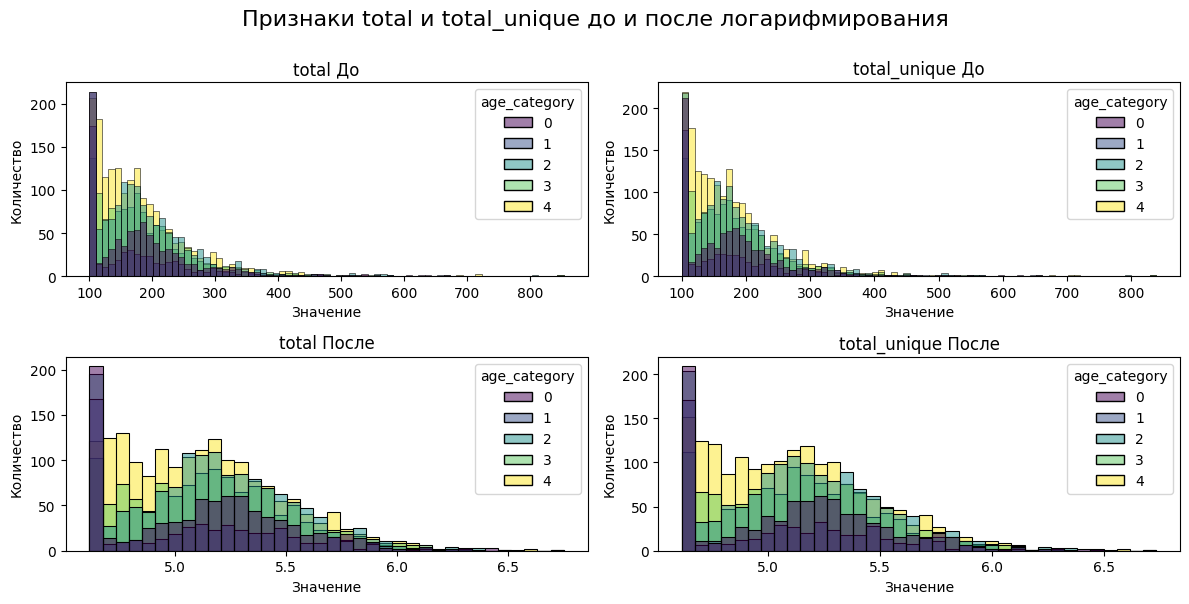

In [15]:
fig, axes = plt.subplots(2, 2, 
                         figsize=(12, 6))

df_new = df.copy()
draw_histogram_grid(
        df_new,
        "total",
        "total До", 
        "Значение",
        "Количество",  
        ax=axes[0, 0],
        hue='age_category',
        palette='viridis'
        )

draw_histogram_grid(
        df_new,
        "total_unique",
        "total_unique До", 
        "Значение",
        "Количество",  
        ax=axes[0, 1],
        hue='age_category',
        palette='viridis'
        )
df_new['total'] = np.log1p(df_new['total'])
df_new['total_unique'] = np.log1p(df_new['total_unique'])
draw_histogram_grid(
        df_new,
        "total",
        "total После", 
        "Значение",
        "Количество",  
        ax=axes[1, 0],
        hue='age_category',
        palette='viridis'
        )

draw_histogram_grid(
        df_new,
        "total_unique",
        "total_unique После", 
        "Значение",
        "Количество",  
        ax=axes[1, 1],
        hue='age_category',
        palette='viridis'
        )

plt.suptitle("Признаки total и total_unique до и после логарифмирования", fontsize=16, y=1)
plt.tight_layout()
plt.show()

#### 2.4. Анализ корреляций признаков
- Построим матрицу корреляций имеющихся признаков:

interval columns not set, guessing: ['age_category', 'count_morning', 'nunique_morning', 'count_day', 'nunique_day', 'count_evening', 'nunique_evening', 'count_night', 'nunique_night', 'total', 'total_unique', 'cat_01', 'cat_02', 'cat_03', 'cat_04', 'cat_05', 'cat_06', 'cat_07', 'cat_08', 'cat_09', 'cat_10', 'cat_11', 'cat_12', 'cat_13', 'cat_14', 'cat_15', 'cat_16', 'cat_17', 'cat_18', 'cat_19', 'cat_20']


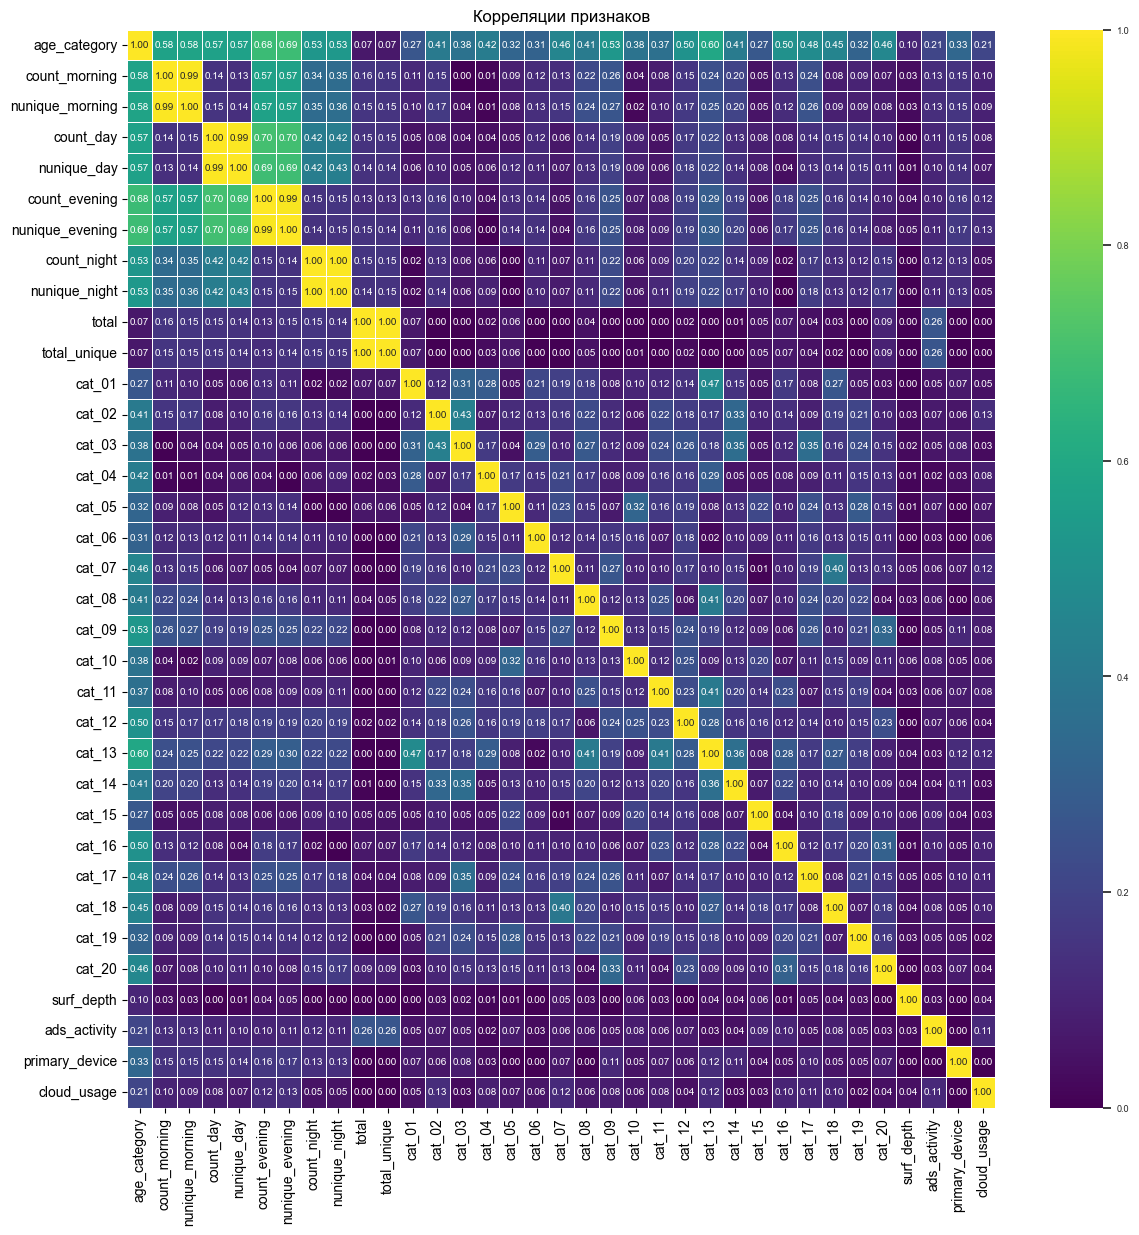

In [16]:
phik_matrix = phik.phik_matrix(df[[target] + num_features + cat_features + bool_features])
draw_heatmap(phik_matrix,
             "Корреляции признаков")

- На диаграмме видны сильные корреляции признаков количества запросов (`count_morning` и т.д.) и количества уникальных сессий (`nunique_morning` и т.д.). Признаки количества уникальных сессий можно удалить.
- Признаки количества запросов по времени суток также показывают высокое значение коэффициентов корреляции. Все эти признаки линейно зависимы, так как в сумме всегда дают 1. Имеет смысл удалить один из признаков `count_day` и `count_evening`, которые коррелируют друг с другом более других.
- В наибольшей степени целевая переменная коррелирует с признаками, отражающими активность пользователя по времени суток. Также высока корреляция с посещаемостью некоторых категорий сайтов: `cat_13`, `cat_12`, `cat_09`, `cat_16`. Самая низкая корреляция - с суммарным количеством посещений и количеством уникальных сессий, а также - с признаком `surf_depth`.

#### 2.5. Выводы
- Классы целевой переменной `age_category` не сбалансированы. Самый многочисленный класс более, чем в 3 раза превосходит самый маленький.
- По категориальным признакам заметны различия в профилях поведения пользователей из различных возрастных групп.
- Наибольшую активность в просмотре рекламы проявляют пользователи среднего возраста.
- Пользователи старшего возраста чаще пользуются ПК как основным устройством. Пользователи младшего возраста редко используют ноутбук.
- Профили активности пользователей по времени суток показывают, что утром и днём выше относительная активность пользователей старшего возраста, а вечером и ночью - наоборот.
- Профили посещаемости различных категорий сайтов демонстрируют различие в поведении пользователей разных возрастных категорий. Нулевые значения в столбцах не являются аномальными значениями, они также распределены по возрастным категориями по-разному и важны для классификации, так как показывают, какие категории сайтов вообще не посещаются пользователями.
- Распределения признаков `total` и `total_unique` сильно скошены, это следует исправить логарифмированием или извлечением квадратного корня.
- В наибольшей степени целевая переменная коррелирует с признаками, отражающими активность пользователя по времени суток. Также высока корреляция с посещаемостью некоторых категорий сайтов: `cat_13`, `cat_12`, `cat_09`, `cat_16`. Самая низкая корреляция - с суммарным количеством посещений и количеством уникальных сессий, а также - с признаком `surf_depth`.
- По результатам анализа корреляций признаков между собой можно удалить признаки, отражающие количество уникальных сессий (`nunique_***`), а также признак `count_day`

- По результатам EDA подготовим функцию для получения датасета из набора таблиц и его базовой предобработки с целью формирования признаков.
<br><br>**NB:** Все операции по агрегации и преобразованию признаков на этом этапе не приводят к утечке данных, так как они производятся над группами данных, относящихся только к одному пользователю (`user_id`), а по условию задачи все данные, относящиеся к одному пользователю, должны целиком попасть или в тестовую, или в обучающую выборку.

In [17]:
def prepare_dataset(df_users, df_ads_activity, df_cloud_usage, df_primary_device, df_visits):
    # Удаление явных дубликатов в таблицах с категориальными признаками
    df_users = df_users.dropna()
    df_ads_activity = df_ads_activity.dropna()
    df_cloud_usage = df_cloud_usage.dropna()
    df_primary_device = df_primary_device.dropna()
    
    df_visits_agg = aggregate_visits(df_visits)
    df = join_tables(df_users, df_ads_activity, df_cloud_usage, df_primary_device, df_visits_agg)
    df = update_features(df)
    
    return df

## 3. Разделение датасета на выборки и описание пайплайнов
#### 3.1. Разделение датасета на выборки
- Разделим датасет на обучающую и тестовую выборки в отношении 4:1:

Размер обучающей выборки: 4660
Размер тестовой выборки: 1166


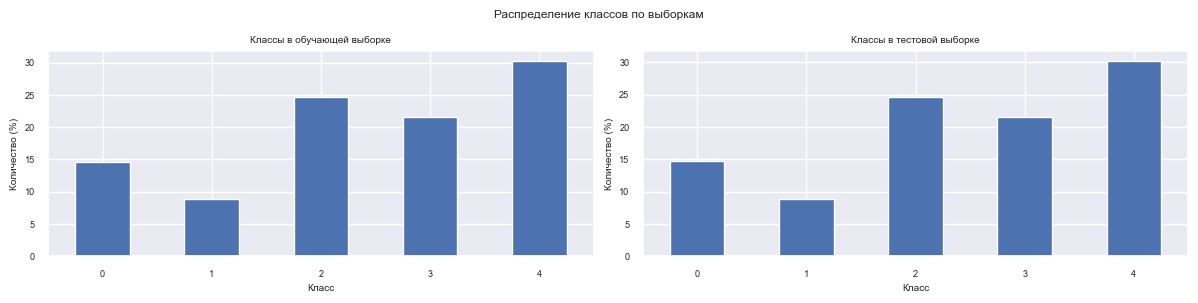

In [18]:
df = prepare_dataset(df_users,
                     df_ads_activity,
                     df_cloud_usage,
                     df_primary_device,
                     df_visits)

# Закомментированы признаки, удаленные по результатам EDA
num_features = [
    'count_morning',
#    'nunique_morning',
#    'count_day',
#    'nunique_day',
    'count_evening',
#    'nunique_evening',
    'count_night',
#    'nunique_night',
    'total'
#   'total_unique'
]
num_features.extend([f'cat_{i:02}' for i in range(1, 21)])

cat_features = [
    'surf_depth',
    'ads_activity',
    'primary_device'
]

bool_features = ['cloud_usage']
target = 'age_category'

all_features = num_features + cat_features + bool_features

X = df.drop(columns=target)[all_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    shuffle=True,
                                                    random_state=RANDOM_SEED,
                                                    stratify=y)

print("Размер обучающей выборки:", len(X_train))
print("Размер тестовой выборки:", len(X_test))
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
draw_barplot_grid(y_train.value_counts().sort_index() / len(y_train) * 100,
                  "Классы в обучающей выборке",
                  "Класс",
                  "Количество (%)",
                  0,
                  True,
                  None, 
                  axes[0])
draw_barplot_grid(y_test.value_counts().sort_index() / len(y_test) * 100,
                  "Классы в тестовой выборке",
                  "Класс",
                  "Количество (%)",
                  0,
                  True,
                  None, 
                  axes[1])
plt.suptitle("Распределение классов по выборкам")
plt.tight_layout()
plt.show()

Распределения классов в обучающей и тестовой выборках совпадают.

#### 3.2. Описание функций для построения пайплайнов
- Опишем построение пайплайна для базовой предобработки данных:
    1. Кодирование категориальных признаков при помощи One Hot Encoding.
    2. Масштабирование числовых признаков при помощи `StandardScaler`.

In [19]:
# Функция для создания пайплайна предобработки
def create_pp_pipeline(num_features, cat_features, feature_engineering):
    # Собранный препроцессинг
    rv = Pipeline([
            ('feature_eng', FunctionTransformer(feature_engineering, validate=False)),
            ('ct', ColumnTransformer([
                ('cat_ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features),
                ('num', StandardScaler(), num_features)
            ]))
    ])

    rv.set_output(transform="pandas")
    return rv

# Функция для создания пайплайна предобработки и классификации
def create_pipeline(num_features, cat_features, feature_engineering, classifier):
    preprocess = create_pp_pipeline(num_features, cat_features, feature_engineering)

    return Pipeline([
        ('preprocess', preprocess),
        ('classify', classifier)
    ])

## 4. Отбор признаков
- Установим предельное значение количества отбираемых признаков для каждого метода отбора:

In [20]:
N_FEATURES_TO_SELECT = 20

#### 4.1. Корреляции целевой переменной

interval columns not set, guessing: ['cat_ohe__surf_depth_Unknown', 'cat_ohe__surf_depth_глубоко', 'cat_ohe__surf_depth_поверхностно', 'cat_ohe__surf_depth_средне', 'cat_ohe__ads_activity_Unknown', 'cat_ohe__ads_activity_очень редко', 'cat_ohe__ads_activity_очень часто', 'cat_ohe__ads_activity_редко', 'cat_ohe__ads_activity_умеренно', 'cat_ohe__ads_activity_часто', 'cat_ohe__primary_device_Unknown', 'cat_ohe__primary_device_ПК', 'cat_ohe__primary_device_ноутбук', 'cat_ohe__primary_device_планшет', 'cat_ohe__primary_device_смартфон', 'num__count_morning', 'num__count_evening', 'num__count_night', 'num__total', 'num__cat_01', 'num__cat_02', 'num__cat_03', 'num__cat_04', 'num__cat_05', 'num__cat_06', 'num__cat_07', 'num__cat_08', 'num__cat_09', 'num__cat_10', 'num__cat_11', 'num__cat_12', 'num__cat_13', 'num__cat_14', 'num__cat_15', 'num__cat_16', 'num__cat_17', 'num__cat_18', 'num__cat_19', 'num__cat_20', 'num__cloud_usage', 'age_category']


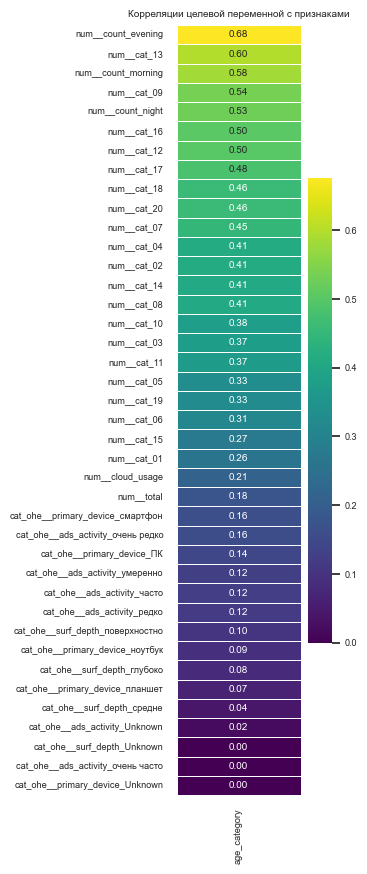

{'num__cat_02',
 'num__cat_03',
 'num__cat_04',
 'num__cat_05',
 'num__cat_07',
 'num__cat_08',
 'num__cat_09',
 'num__cat_10',
 'num__cat_11',
 'num__cat_12',
 'num__cat_13',
 'num__cat_14',
 'num__cat_16',
 'num__cat_17',
 'num__cat_18',
 'num__cat_19',
 'num__cat_20',
 'num__count_evening',
 'num__count_morning',
 'num__count_night'}

In [21]:
def feature_engineering(X):
    X_new = X.copy()
    X_new['total'] = np.log1p(X['total'])
    return X_new

pp = create_pp_pipeline(num_features + bool_features, cat_features, feature_engineering)
X_train_pp = pp.fit_transform(X_train, y_train)
X_train_pp.index = y_train.index

corr_matrix = (phik.phik_matrix(pd.concat([X_train_pp, y_train], axis=1))[[target]]
               .sort_values(by=target, ascending=False)
               .drop(target))
#corr_matrix = pd.concat([X_train_corr, y_train], axis=1).corr()
draw_heatmap(corr_matrix, "Корреляции целевой переменной с признаками", figsize=(2, 10))

features_to_keep_corr = set(corr_matrix.iloc[:N_FEATURES_TO_SELECT].index.to_list())
display(HTML("<b>Отобранные признаки:<b>"))
display(features_to_keep_corr)

#### 4.2. Метрика взаимной информации с целевой переменной (Mutual Information)

- Получим признаки с максимальной метрикой взаимной информации с целевой переменной:

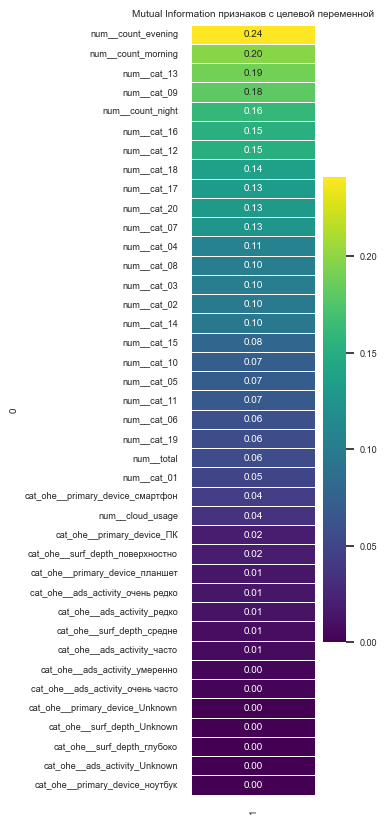

{'num__cat_02',
 'num__cat_03',
 'num__cat_04',
 'num__cat_05',
 'num__cat_07',
 'num__cat_08',
 'num__cat_09',
 'num__cat_10',
 'num__cat_11',
 'num__cat_12',
 'num__cat_13',
 'num__cat_14',
 'num__cat_15',
 'num__cat_16',
 'num__cat_17',
 'num__cat_18',
 'num__cat_20',
 'num__count_evening',
 'num__count_morning',
 'num__count_night'}

In [22]:
mi_scores = mutual_info_classif(X_train_pp, y_train, random_state=RANDOM_SEED)
top_idx = sorted(range(len(X_train_pp.columns)), 
                 key = lambda i: mi_scores[i], reverse=True)
df_mi_features = pd.DataFrame([(X_train_pp.columns[i], mi_scores[i]) for i in top_idx])
df_mi_features.set_index(0, inplace=True)
draw_heatmap(df_mi_features, 
             "Mutual Information признаков с целевой переменной", figsize=(2, 10))
features_to_keep_mi = {X_train_pp.columns[i] for i in top_idx[:N_FEATURES_TO_SELECT]}
display(HTML("<b>Отобранные признаки:<b>"))
display(features_to_keep_mi)

#### 4.3. Методы-обёртки (Recursive Feature Elimination)
- Получим самые значимые признаки методом обратного отбора с использованием `RFE`:

In [23]:
lr_estimator = LogisticRegression(random_state=RANDOM_SEED, solver='lbfgs', max_iter=1000)

rfe_selector = RFE(lr_estimator, step=1, n_features_to_select=N_FEATURES_TO_SELECT)

rfe_selector.fit(X_train_pp, y_train)

final_support = rfe_selector.support_
features_to_keep_lr_rfe = {X_train_pp.columns[i] for i in np.where(final_support)[0]}

display(HTML("<b>Отобранные признаки:<b>"))
display( features_to_keep_lr_rfe)

{'cat_ohe__ads_activity_Unknown',
 'cat_ohe__ads_activity_умеренно',
 'cat_ohe__ads_activity_часто',
 'cat_ohe__primary_device_ПК',
 'cat_ohe__primary_device_ноутбук',
 'num__cat_03',
 'num__cat_04',
 'num__cat_07',
 'num__cat_08',
 'num__cat_09',
 'num__cat_10',
 'num__cat_12',
 'num__cat_13',
 'num__cat_15',
 'num__cat_16',
 'num__cat_17',
 'num__cat_18',
 'num__cat_20',
 'num__count_evening',
 'num__count_night'}

#### 4.4. Константные признаки

- Исследуем признаки с малой дисперсией:

In [24]:
vs_constant = VarianceThreshold(threshold=0.001) 
vs_constant.fit(X_train_pp)
features_to_delete_const = {X for X, keep in zip(X_train_pp.columns,
                                                 vs_constant.get_support()) if not keep}
display(HTML("<b>Константные признаки (дисперсия < 0.001):</b>"))
display(features_to_delete_const)

set()

Признаков с дисперсией ниже 0.001 не найдено.

#### 4.5. Формирование набора признаков для обучения
- Объединим наборы признаков, полученные на предыдущих этапах:

In [25]:
selected_features = (features_to_keep_corr | 
                     features_to_keep_mi | 
                     features_to_keep_lr_rfe) - features_to_delete_const

display(HTML(f"<b>Осталось {len(selected_features)} признаков из {len(X_train_pp.columns)}: </b>"))
display(selected_features)

{'cat_ohe__ads_activity_Unknown',
 'cat_ohe__ads_activity_умеренно',
 'cat_ohe__ads_activity_часто',
 'cat_ohe__primary_device_ПК',
 'cat_ohe__primary_device_ноутбук',
 'num__cat_02',
 'num__cat_03',
 'num__cat_04',
 'num__cat_05',
 'num__cat_07',
 'num__cat_08',
 'num__cat_09',
 'num__cat_10',
 'num__cat_11',
 'num__cat_12',
 'num__cat_13',
 'num__cat_14',
 'num__cat_15',
 'num__cat_16',
 'num__cat_17',
 'num__cat_18',
 'num__cat_19',
 'num__cat_20',
 'num__count_evening',
 'num__count_morning',
 'num__count_night'}

## 5. Обучение моделей
- Оценим на кросс-валидации из 5 фолдов три модели:
    1. `DummyClassifier` со стратификацией (базовая модель).
    2. `LogisticRegression` с параметрами по умолчанию.
    3. `SVC` с `OneVsRestClassifier` и параметрами по умолчанию.
- Для каждой модели выведем метрики по кросс-валидации Accuracy, Precision, Recall, F1 с макроусреднением, а также `classification_report` по обучающей выборке.
- Опишем функцию для вычисления метрик:

In [26]:
# Функция для расчета метрик
def calc_metrics(y, y_pred_proba, average='macro', prefix='train_'):
    is_proba = True
    if len(y_pred_proba.shape) == 1:
        y_pred = y_pred_proba
        is_proba = False
    else:
        y_pred = np.argmax(y_pred_proba, axis=1)
    return {(prefix + 'accuracy'): accuracy_score(y, y_pred),
            (prefix + 'f1' + "_" + average): f1_score(y, y_pred, average=average),
            # (prefix + 'average_precision' + "_" + average): average_precision_score(y, y_pred_proba, average=average) if is_proba else 0,
            (prefix + 'precision' + "_" + average): precision_score(y, y_pred, zero_division=0, average=average),
            (prefix + 'recall' + "_" + average): recall_score(y, y_pred, average=average)}

#### 5.1. Обучение базовой модели `DummyClassifier`
- Обучим модель `DummyClassifier` со стратегией стратификации (классы распределены случайно согласно их частоте в обучающей выборке):

In [27]:
# 5 фолдов со стратификацией
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

dummy_pipeline = create_pipeline(num_features,
                                 cat_features,
                                 feature_engineering,
                                 DummyClassifier(random_state=RANDOM_SEED,
                                                 strategy='stratified'))


dummy_metrics = cross_validate(dummy_pipeline, 
                               X_train, 
                               y_train, 
                               scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
                               cv=cv,
                               n_jobs=-1
)

dummy_pipeline.fit(X_train, y_train)
y_train_dummy_pred = dummy_pipeline.predict(X_train)

# Выведем метрики классификации модели на обучающей выборке
print(classification_report(y_train, y_train_dummy_pred))

dummy_metrics_cv = pd.DataFrame(dummy_metrics).iloc[:, 3:].mean()
dummy_metrics_train = calc_metrics(y_train, y_train_dummy_pred)
display(dummy_metrics_cv)

              precision    recall  f1-score   support

           0       0.14      0.14      0.14       682
           1       0.09      0.09      0.09       411
           2       0.25      0.24      0.25      1151
           3       0.23      0.24      0.23      1003
           4       0.30      0.31      0.31      1413

    accuracy                           0.23      4660
   macro avg       0.20      0.20      0.20      4660
weighted avg       0.23      0.23      0.23      4660



test_precision_macro    0.215079
test_recall_macro       0.215251
test_f1_macro           0.215036
dtype: float64

#### 5.2. Обучение модели многоклассовой логистической регрессии с параметрами по умолчанию

In [28]:
lr_default_pipeline = create_pipeline(num_features,
                                      cat_features,
                                      feature_engineering,
                                      LogisticRegression(solver='lbfgs', 
                                                         random_state=RANDOM_SEED))

lr_default_metrics = cross_validate(lr_default_pipeline, 
                               X_train, 
                               y_train, 
                               scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
                               cv=cv,
                               n_jobs=-1
)

lr_default_pipeline.fit(X_train, y_train)
y_train_lr_default_pred_proba = lr_default_pipeline.predict_proba(X_train)
y_train_lr_default_pred = lr_default_pipeline.predict(X_train)

lr_default_metrics_cv = pd.DataFrame(lr_default_metrics).iloc[:, 3:].mean()
lr_default_metrics_train = calc_metrics(y_train, y_train_lr_default_pred)

# Выведем метрики классификации модели на обучающей выборке
print(classification_report(y_train, y_train_lr_default_pred))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87       682
           1       0.74      0.63      0.68       411
           2       0.85      0.87      0.86      1151
           3       0.85      0.85      0.85      1003
           4       0.90      0.92      0.91      1413

    accuracy                           0.86      4660
   macro avg       0.84      0.83      0.83      4660
weighted avg       0.86      0.86      0.86      4660



- Сравним полученные результаты кросс-валидации для логистической регрессии с базовой моделью (с макроусреднением)

In [29]:
display(pd.DataFrame({
    "DummyClassifier": dummy_metrics_cv,
    "LogisticRegression (default)": lr_default_metrics_cv
}))

,DummyClassifier,LogisticRegression (default)
test_precision_macro,0.215079,0.822438
test_recall_macro,0.215251,0.808829
test_f1_macro,0.215036,0.813885


- Видно, что обучение прошло успешно, по всем метрикам модель показывает в 4 раза лучшие результаты, чем `DummyClassifier`

#### 5.3. Обучение модели `SVC` с параметрами по умолчанию и `OneVsRestClassifier`

In [30]:
svc_ovr_default_pipeline = create_pipeline(num_features,
                                          cat_features,
                                          feature_engineering,
                                          SVC(random_state=RANDOM_SEED))
svc_ovr_default = OneVsRestClassifier(estimator=svc_ovr_default_pipeline,
                                     n_jobs=-1)

svc_ovr_default_metrics = cross_validate(svc_ovr_default, 
                               X_train, 
                               y_train, 
                               scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
                               cv=cv,
                               n_jobs=-1
)

svc_ovr_default.fit(X_train, y_train)
y_train_sc_ovr_pred = svc_ovr_default.predict(X_train)

svc_ovr_default_metrics_cv = pd.DataFrame(svc_ovr_default_metrics).iloc[:, 3:].mean()
svc_ovr_default_metrics_train = calc_metrics(y_train, y_train_sc_ovr_pred)

print(classification_report(y_train, y_train_sc_ovr_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       682
           1       0.96      0.89      0.92       411
           2       0.96      0.97      0.96      1151
           3       0.96      0.97      0.97      1003
           4       0.98      0.99      0.98      1413

    accuracy                           0.97      4660
   macro avg       0.96      0.96      0.96      4660
weighted avg       0.97      0.97      0.97      4660



- Сравним результаты трех моделей на кросс-валидации:

In [31]:
display(pd.DataFrame({
    "DummyClassifier": dummy_metrics_cv,
    "LogisticRegression (default)": lr_default_metrics_cv,
    'SVC OVR (default)': svc_ovr_default_metrics_cv
}))

,DummyClassifier,LogisticRegression (default),SVC OVR (default)
test_precision_macro,0.215079,0.822438,0.917766
test_recall_macro,0.215251,0.808829,0.903070
test_f1_macro,0.215036,0.813885,0.909194


- Метрики по предсказанию на обучающей выборке:

In [32]:
display(pd.DataFrame({
    "DummyClassifier": dummy_metrics_train,
    "LogisticRegression (default)": lr_default_metrics_train,
    "SVC OVR (default)": svc_ovr_default_metrics_train
}))

,DummyClassifier,LogisticRegression (default),SVC OVR (default)
train_accuracy,0.233476,0.859013,0.966738
train_f1_macro,0.204547,0.832771,0.959762
train_precision_macro,0.204590,0.839813,0.964232
train_recall_macro,0.204629,0.827512,0.955802


- Видно, что модель `SVC` с `OneVsRestClassificator` на кросс-валидации показывает еще лучшие результаты, чем логистическая регрессия.
- По результатам анализа метрик по классам в `classification_report` видно, что многоклассовая логистическая регрессия хуже всего распознает класс 1, являющийся самым малочисленным (оценка F1 0.68 против 0.85-0.86 на более многочисленных классах). Модель `SVC` с `OneVsRestClassifier` дает более стабильные результаты на всех классах.

## 6. Подбор гиперпараметров
Используем `GridSearchCV` для подбора гиперпараметров моделей и выбора наилучшего набора.
#### 6.1. Подбор гиперпараметров логистической регрессии

In [33]:
lr_param_grid = [
    {
        "classify__solver": ['lbfgs'],
        "classify__C": [0.01, 0.1, 1, 10, 100],
        "classify__class_weight": [None, 'balanced']
    },
    {
        "classify__solver": ['saga'],
        "classify__penalty": ["l1"],
        "classify__C": [0.1, 1, 10],
        "classify__max_iter": [1000],
        "classify__class_weight": [None, 'balanced']
    },
    {
        "classify__solver": ['saga'],
        "classify__penalty": ["elasticnet"],
        "classify__l1_ratio": [0, 0.5, 1],
        "classify__C": [0.1, 1, 10],
        "classify__max_iter": [1000],
        "classify__class_weight": [None, 'balanced']
    }
]

- Запустим подбор параметров по заданной сетке и выведем результат:

In [34]:
# Обработка результатов
def top_10_results(lr_grid):
    lr_grid_results = pd.DataFrame(lr_grid.cv_results_)
    lr_grid_results = lr_grid_results.sort_values(by=["rank_test_score"])
    lr_grid_results = lr_grid_results.set_index(
        lr_grid_results["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
        ).rename_axis("kernel")
    lr_grid_results['model'] = lr_grid.estimator.named_steps['classify']
    return lr_grid_results[["params", "model", "mean_test_score", "std_test_score"]][:10]

lr_grid_pipeline = create_pipeline(num_features,
                                   cat_features,
                                   feature_engineering,
                                   LogisticRegression(random_state=RANDOM_SEED))

lr_grid = GridSearchCV(lr_grid_pipeline,
                       lr_param_grid,
                       scoring='f1_macro',
                       cv=cv,
                       n_jobs=-1,
                       return_train_score=True,
                       verbose=1)
lr_grid.fit(X_train, y_train)

display(pd.DataFrame(top_10_results(lr_grid)))

Fitting 5 folds for each of 34 candidates, totalling 170 fits


c:\Users\TEXNH MAKPH\Projects\Yandex DS\ds-yandex\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,params,model,mean_test_score,std_test_score
kernel,,,,
1_None_0.5_1000_elasticnet_saga,"{'classify__C': 1, 'classify__class_weight': N...",LogisticRegression(random_state=42),0.815630,0.019997
0.1_None_lbfgs,"{'classify__C': 0.1, 'classify__class_weight':...",LogisticRegression(random_state=42),0.815456,0.020821
0.1_None_0_1000_elasticnet_saga,"{'classify__C': 0.1, 'classify__class_weight':...",LogisticRegression(random_state=42),0.814867,0.021204
1_None_1000_l1_saga,"{'classify__C': 1, 'classify__class_weight': N...",LogisticRegression(random_state=42),0.814422,0.019316
1_None_1_1000_elasticnet_saga,"{'classify__C': 1, 'classify__class_weight': N...",LogisticRegression(random_state=42),0.814422,0.019316
1_None_0_1000_elasticnet_saga,"{'classify__C': 1, 'classify__class_weight': N...",LogisticRegression(random_state=42),0.814246,0.019676
10_None_1000_l1_saga,"{'classify__C': 10, 'classify__class_weight': ...",LogisticRegression(random_state=42),0.814143,0.019746
10_None_0.5_1000_elasticnet_saga,"{'classify__C': 10, 'classify__class_weight': ...",LogisticRegression(random_state=42),0.814143,0.019746
10_None_1_1000_elasticnet_saga,"{'classify__C': 10, 'classify__class_weight': ...",LogisticRegression(random_state=42),0.814143,0.019746


#### 6.2. Подбор гиперпараметров `SVC`

In [35]:
svc_param_grid = [
    {
        "classify__estimator__kernel": ['linear'],
        "classify__estimator__C": [0.1, 1, 10]
    },
    {
        "classify__estimator__kernel": ['rbf'],
        "classify__estimator__gamma": ['auto', 'scale'],
        "classify__estimator__C": [0.1, 1, 10]
    },
    {
        "classify__estimator__kernel": ['poly'],
        "classify__estimator__gamma": ['auto', 'scale'],
        "classify__estimator__C": [0.1, 1, 10],
        "classify__estimator__degree": [2, 3],
        "classify__estimator__coef0": [0, 0.5, 1]
    }
]

- Подберем параметры для `SVC` с `OneVsRestClassifier`:

In [36]:
svc_ovr_grid_pipeline = create_pipeline(num_features,
                                        cat_features,
                                        feature_engineering,
                                        OneVsRestClassifier(SVC(random_state=RANDOM_SEED),
                                                            n_jobs=-1))

svc_ovr_grid = GridSearchCV(svc_ovr_grid_pipeline,
                       svc_param_grid,
                       scoring='f1_macro',
                       cv=cv,
                       n_jobs=-1,
                       return_train_score=True,
                       verbose=1)
svc_ovr_grid.fit(X_train, y_train)

display(pd.DataFrame(top_10_results(svc_ovr_grid)))

Fitting 5 folds for each of 45 candidates, totalling 225 fits


,params,model,mean_test_score,std_test_score
kernel,,,,
1_0.5_3_auto_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsRestClassifier(estimator=SVC(random_state...,0.909813,0.016266
1_scale_rbf,"{'classify__estimator__C': 1, 'classify__estim...",OneVsRestClassifier(estimator=SVC(random_state...,0.909194,0.016980
1_0.5_3_scale_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsRestClassifier(estimator=SVC(random_state...,0.907772,0.016476
1_1_2_scale_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsRestClassifier(estimator=SVC(random_state...,0.906337,0.017859
1_1_3_auto_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsRestClassifier(estimator=SVC(random_state...,0.906244,0.016911
1_0.5_2_scale_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsRestClassifier(estimator=SVC(random_state...,0.904905,0.017960
1_0_2_scale_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsRestClassifier(estimator=SVC(random_state...,0.903888,0.015178
1_auto_rbf,"{'classify__estimator__C': 1, 'classify__estim...",OneVsRestClassifier(estimator=SVC(random_state...,0.903256,0.015301
1_1_3_scale_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsRestClassifier(estimator=SVC(random_state...,0.901728,0.020204


- Подберем параметры для `SVC` с `OneVsOneClassifier`:

In [37]:
svc_ovo_grid_pipeline = create_pipeline(num_features,
                                        cat_features,
                                        feature_engineering,
                                        OneVsOneClassifier(SVC(random_state=RANDOM_SEED),
                                                            n_jobs=-1))

svc_ovo_grid = GridSearchCV(svc_ovo_grid_pipeline,
                       svc_param_grid,
                       scoring='f1_macro',
                       cv=cv,
                       n_jobs=-1,
                       return_train_score=True,
                       verbose=1)
svc_ovo_grid.fit(X_train, y_train)

display(pd.DataFrame(top_10_results(svc_ovo_grid)))

Fitting 5 folds for each of 45 candidates, totalling 225 fits


,params,model,mean_test_score,std_test_score
kernel,,,,
1_scale_rbf,"{'classify__estimator__C': 1, 'classify__estim...",OneVsOneClassifier(estimator=SVC(random_state=...,0.908110,0.013075
1_0_2_scale_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsOneClassifier(estimator=SVC(random_state=...,0.905682,0.017455
1_0.5_3_auto_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsOneClassifier(estimator=SVC(random_state=...,0.905324,0.015636
1_0_2_auto_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsOneClassifier(estimator=SVC(random_state=...,0.903138,0.015957
1_0.5_2_scale_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsOneClassifier(estimator=SVC(random_state=...,0.902228,0.017627
1_auto_rbf,"{'classify__estimator__C': 1, 'classify__estim...",OneVsOneClassifier(estimator=SVC(random_state=...,0.901057,0.012065
1_1_2_scale_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsOneClassifier(estimator=SVC(random_state=...,0.899918,0.014835
1_0.5_3_scale_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsOneClassifier(estimator=SVC(random_state=...,0.899709,0.016895
1_1_3_auto_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsOneClassifier(estimator=SVC(random_state=...,0.899058,0.016560


- Объединим оценки и найдем лучшую модель:

In [38]:
metrics_result = pd.concat([top_10_results(lr_grid),
                            top_10_results(svc_ovr_grid),
                            top_10_results(svc_ovo_grid)]).sort_values(by='mean_test_score', 
                                                                        ascending=False).iloc[:10]
display(metrics_result)

,params,model,mean_test_score,std_test_score
kernel,,,,
1_0.5_3_auto_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsRestClassifier(estimator=SVC(random_state...,0.909813,0.016266
1_scale_rbf,"{'classify__estimator__C': 1, 'classify__estim...",OneVsRestClassifier(estimator=SVC(random_state...,0.909194,0.016980
1_scale_rbf,"{'classify__estimator__C': 1, 'classify__estim...",OneVsOneClassifier(estimator=SVC(random_state=...,0.908110,0.013075
1_0.5_3_scale_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsRestClassifier(estimator=SVC(random_state...,0.907772,0.016476
1_1_2_scale_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsRestClassifier(estimator=SVC(random_state...,0.906337,0.017859
1_1_3_auto_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsRestClassifier(estimator=SVC(random_state...,0.906244,0.016911
1_0_2_scale_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsOneClassifier(estimator=SVC(random_state=...,0.905682,0.017455
1_0.5_3_auto_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsOneClassifier(estimator=SVC(random_state=...,0.905324,0.015636
1_0.5_2_scale_poly,"{'classify__estimator__C': 1, 'classify__estim...",OneVsRestClassifier(estimator=SVC(random_state...,0.904905,0.017960


- Лучшие результаты показывает модель `SVC` с полиномиальным ядром степени 3, значением параметра регуляризации `C` = 1, свободным коэфициентом 0.5, параметром `gamma` = `auto`, обернутая в `OneVsRestClassifier`.

## 7. Обучение финальной модели
- Обучим модель с лучшими параметрами

In [39]:
best_params = {
    k.replace('classify__estimator__', ''): v
        for k, v in metrics_result['params'].iloc[0].items()
}

final_pipeline = create_pipeline(num_features,
                                cat_features,
                                feature_engineering,
                                OneVsRestClassifier(SVC(random_state=RANDOM_SEED, 
                                                        **best_params),
                                                    n_jobs=-1))
final_pipeline.fit(X_train, y_train)
y_train_final_pred = final_pipeline.predict(X_train)
display(HTML("<h3>Результаты прогнозирования на обучающей выборке</h3>"))
print(classification_report(y_train, y_train_final_pred))

y_test_pred = final_pipeline.predict(X_test)
display(HTML("<h3>Результаты прогнозирования на тестовой выборке</h3>"))
print(classification_report(y_test, y_test_pred))


              precision    recall  f1-score   support

           0       0.96      0.96      0.96       682
           1       0.95      0.91      0.93       411
           2       0.96      0.97      0.96      1151
           3       0.97      0.97      0.97      1003
           4       0.98      0.99      0.99      1413

    accuracy                           0.97      4660
   macro avg       0.96      0.96      0.96      4660
weighted avg       0.97      0.97      0.97      4660



              precision    recall  f1-score   support

           0       0.88      0.89      0.89       171
           1       0.83      0.83      0.83       103
           2       0.91      0.91      0.91       288
           3       0.93      0.91      0.92       251
           4       0.93      0.95      0.94       353

    accuracy                           0.91      1166
   macro avg       0.90      0.90      0.90      1166
weighted avg       0.91      0.91      0.91      1166



- Финальная модель на тестовых данных показывает немного худшие результаты, чем на обучающих, однако небольшая разница говорит о том, что переобучение незначительно.
- Меньшие по объему классы модель распознает чуть хуже, чем более многочисленные, но разница некритична.

- Получим предсказания всех моделей на тестовой выборке и построим единую таблицу метрик:

In [40]:
# Базовая модель DummyClassifier
y_test_pred_dummy = dummy_pipeline.predict(X_test)
dummy_metrics_train.update(calc_metrics(y_test, y_test_pred_dummy, prefix='test_'))

# Модель LogisticRegression с параметрами по умолчанию
y_test_pred_lr = lr_default_pipeline.predict(X_test)
lr_default_metrics_train.update(calc_metrics(y_test, y_test_pred_lr, prefix='test_'))

# Модель LogisticRegression с параметрами по умолчанию
y_test_pred_svc_ovr = svc_ovr_default.predict(X_test)
svc_ovr_default_metrics_train.update(calc_metrics(y_test, y_test_pred_svc_ovr, prefix='test_'))

# Выбранная модель с оптимальными параметрами
final_metrics = calc_metrics(y_train, y_train_final_pred)
final_metrics.update(calc_metrics(y_test, y_test_pred, prefix='test_'))

display(pd.DataFrame({
    "DummyClassifier": dummy_metrics_train,
    "LogisticRegression (default)": lr_default_metrics_train,
    "SVC OVR (default)": svc_ovr_default_metrics_train,
    "Final model": final_metrics
}))

,DummyClassifier,LogisticRegression (default),SVC OVR (default),Final model
train_accuracy,0.233476,0.859013,0.966738,0.967382
train_f1_macro,0.204547,0.832771,0.959762,0.961040
train_precision_macro,0.204590,0.839813,0.964232,0.964095
train_recall_macro,0.204629,0.827512,0.955802,0.958207
test_accuracy,0.221269,0.828473,0.912521,0.909949
test_f1_macro,0.193850,0.794825,0.899455,0.896107
test_precision_macro,0.193989,0.797134,0.900237,0.896791
test_recall_macro,0.193773,0.793118,0.898856,0.895551


- Построим Confusion Matrix для финальной модели и `SVC` с параметрами по умолчанию:

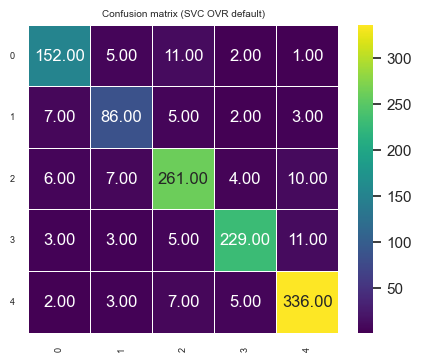

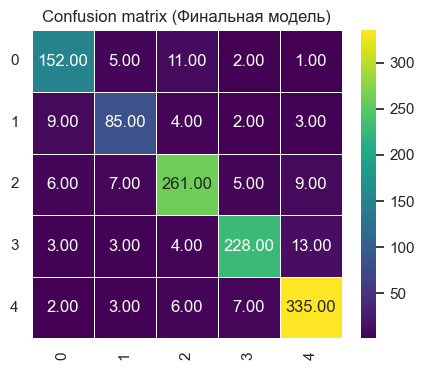

In [41]:
conf_matrix_def = confusion_matrix(y_test, y_test_pred_svc_ovr)
draw_heatmap(conf_matrix_def,
             "Confusion matrix (SVC OVR default)",
             figsize=(5, 4),
             font_scale=1)

conf_matrix = confusion_matrix(y_test, y_test_pred)
draw_heatmap(conf_matrix,
             "Confusion matrix (Финальная модель)",
             figsize=(5, 4),
             font_scale=1)

- Модель, показавшая лучшие результаты на кросс-валидации, показывает лучшие результаты и на обучающей выборке, однако на тестовой она проигрывает модели `SVC` с `OneVsRestClassifier` и с параметрами по умолчанию - в классах 1, 3, 4 она допускает на одну ошибку больше. Тем не менее, разница незначительна, и для продакшена будет использована модель с лучшими параметрами по результатам анализа.

## 8. Сохранение и проверка артефактов

#### 8.1. Сохранение артефактов

- Сохраним функцию сборки датасета из исходных таблиц и выбранный пайплайн классификации:

In [42]:
PREPARE_DATASET_FILE_NAME = "prepare_dataset.joblib"
PIPELINE_FILE_NAME = "age_cat_prediction.joblib"

try:
    # Сохраним функцию сборки датасета
    joblib.dump(prepare_dataset, PREPARE_DATASET_FILE_NAME)

    # Сохраним пайплайн
    joblib.dump(final_pipeline, PIPELINE_FILE_NAME)
except Exception as e:
    print("Ошибка сохранения артефактов:", e)
    raise

print("Артефакты сохранены")

Артефакты сохранены


#### 8.2. Проверка артефактов
- Проверим корректность работы загруженных артефактов, начиная с исходных датафреймов:

In [43]:
# Функция для проверки подготовки данных и запуска пайплайна
def check_predict_test(prepare_dataset,
                       predict_pipeline,
                       df_users,
                       df_ads_activity,
                       df_cloud_usage,
                       df_primary_device,
                       df_visits):
    
    df = prepare_dataset(df_users,
                         df_ads_activity,
                         df_cloud_usage,
                         df_primary_device,
                         df_visits)
    X = df.drop(columns=[target])
    y = df[target]
    _, X_test, _, y_test = train_test_split(X, y, 
                                            test_size=0.2, 
                                            random_state=RANDOM_SEED, 
                                            shuffle=True, 
                                            stratify=y)
    
    return y_test, predict_pipeline.predict(X_test)

y_test_check, y_test_pred_check = check_predict_test(prepare_dataset,
                                                     final_pipeline,
                                                     df_users,
                                                     df_ads_activity,
                                                     df_cloud_usage,
                                                     df_primary_device,
                                                     df_visits)

try:
    prepare_dataset_loaded = joblib.load(PREPARE_DATASET_FILE_NAME)
    predict_pipeline_loaded = joblib.load(PIPELINE_FILE_NAME)
except Exception as e:
    print("Ошибка загрузки артефактов:", e)
    raise

y_test_load, y_test_pred_load = check_predict_test(prepare_dataset_loaded,
                                                   predict_pipeline_loaded,
                                                   df_users,
                                                   df_ads_activity,
                                                   df_cloud_usage,
                                                   df_primary_device,
                                                   df_visits)

diff_test = np.abs(y_test_load - y_test_check).sum()
diff_pred = np.abs(y_test_pred_load - y_test_pred_check).sum()

if diff_test + diff_pred == 0.0:
    print("Пайплайн сохранен, проверка прошла успешно.")
else:
    print("Ошибка: ", diff_test + diff_pred)

Пайплайн сохранен, проверка прошла успешно.


## 9. Выводы
- Для решения задачи прогнозирования был представлен набор данных, состоящий из 6 таблиц в формате CSV.
- Таблицы были загружены; на этапе первичного анализа данных было установлено, что в таблицах присутствуют дубликаты. Во всех таблицах, кроме `visits`, где дубликаты допустимы, они были удалены.
- Данные по пользователям были агрегированы для формирования пользовательских профилей. Таблицы были соединены в единый датасет, пропуски в категориальных признаках были заполнены заглушками `Unknown`, в булевом признаке - значением `False`.
- В процессе исследовательского анализа данных были исследованы распределения категориальных и числовых признаков. Установлено, что присутствует различие между распределениями в зависимости от целевой переменной (возрастной категории). Явные выбросы отсутствуют, распределения признаков `total` и `total_unique` сильно скошены, они были прологарифмированы.
- В результате исследования корреляций между признаками и целевой переменной установлено, что некоторые признаки сильно коррелируют друг с другом. По одному признаку из пар коррелирующих признаков с коэффициентом корреляции >= 0.99 были удалены.
- Датасет был разделен на обучающую и тестовую выборки в отношении 4:1, сформирован пайплайн для предобработки с масштабированием числовых признаков (стандартизация) и кодированием категориальных признаков (One Hot Encoding).
- В процессе отбора признаков были использованы методы исследования корреляции и меры взаимной информации с целевой переменной, рекурсивного отбора признаков (Recursive Feature Selection), фильтрации константных признаков. Для обучения моделей были выбраны 26 признаков из 40.
- На отобранных признаках были оценены на кросс-валидации и обучены модели:
    1. `DummyClassifier` со стратификацией (базовая модель);
    2. Многоклассовая `LogisticRegression` с параметрами по умолчанию;
    3. `SVC` с параметрами по умолчанию и оберткой `OneVsRestClassifier`.
- В результате подбора гиперпараметров лучшей была выбрана модель `SVC` с полиномиальным ядром степени 3, значением параметра регуляризации `C` = 1, свободным коэфициентом 0.5, параметром `gamma` = `auto`, обернутая в `OneVsRestClassifier`.
- На тестовой выборке лучшая модель показала немного худшие результаты, чем `SVC` с параметрами по умолчанию и оберткой `OneVsRestClassifier`: в классах 1, 3, 4 она сделала на одну ошибку больше.
- Выбранная модель была сохранена на диск, корректность работы сохраненных артефактов проверена.